In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

In [2]:
df = pd.read_csv("../data/customer_churn.csv")
df.head()

,Age,Tenure,MonthlyCharges,SupportCalls,ContractType,Churn
0,25,3,70,4,Month-to-month,Yes
1,45,24,55,1,One year,No
2,32,12,90,3,Month-to-month,Yes
3,60,48,40,0,Two year,No
4,29,6,85,5,Month-to-month,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             10 non-null     int64
 1   Tenure          10 non-null     int64
 2   MonthlyCharges  10 non-null     int64
 3   SupportCalls    10 non-null     int64
 4   ContractType    10 non-null     str  
 5   Churn           10 non-null     str  
dtypes: int64(4), str(2)
memory usage: 612.0 bytes


In [5]:
df.describe()

,Age,Tenure,MonthlyCharges,SupportCalls
count,10.000000,10.000000,10.000000,10.000000
mean,40.000000,20.900000,68.000000,2.500000
std,13.408124,18.027448,18.589125,2.068279
min,23.000000,2.000000,40.000000,0.000000
25%,29.750000,7.000000,56.250000,1.000000
50%,38.000000,15.000000,67.500000,2.500000
75%,50.250000,33.000000,82.500000,3.750000
max,60.000000,50.000000,95.000000,6.000000


In [6]:
df["Churn"].value_counts()

Churn
Yes    5
No     5
Name: count, dtype: int64

In [8]:
df_encoded = pd.get_dummies(df,drop_first=True)
df_encoded.head()

,Age,Tenure,MonthlyCharges,SupportCalls,ContractType_One year,ContractType_Two year,Churn_Yes
0,25,3,70,4,False,False,True
1,45,24,55,1,True,False,False
2,32,12,90,3,False,False,True
3,60,48,40,0,False,True,False
4,29,6,85,5,False,False,True


In [10]:
X= df_encoded.drop("Churn_Yes",axis=1)
y= df_encoded["Churn_Yes"]

In [11]:
X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42) 

In [12]:
model = DecisionTreeClassifier(criterion="gini",
                               max_depth=3,
                               min_samples_split=2,
                               random_state=42)
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [13]:
y_pred = model.predict(X_test)
y_pred

array([ True, False])

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
[[1 0]
 [0 1]]
              precision    recall  f1-score   support

       False       1.00      1.00      1.00         1
        True       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



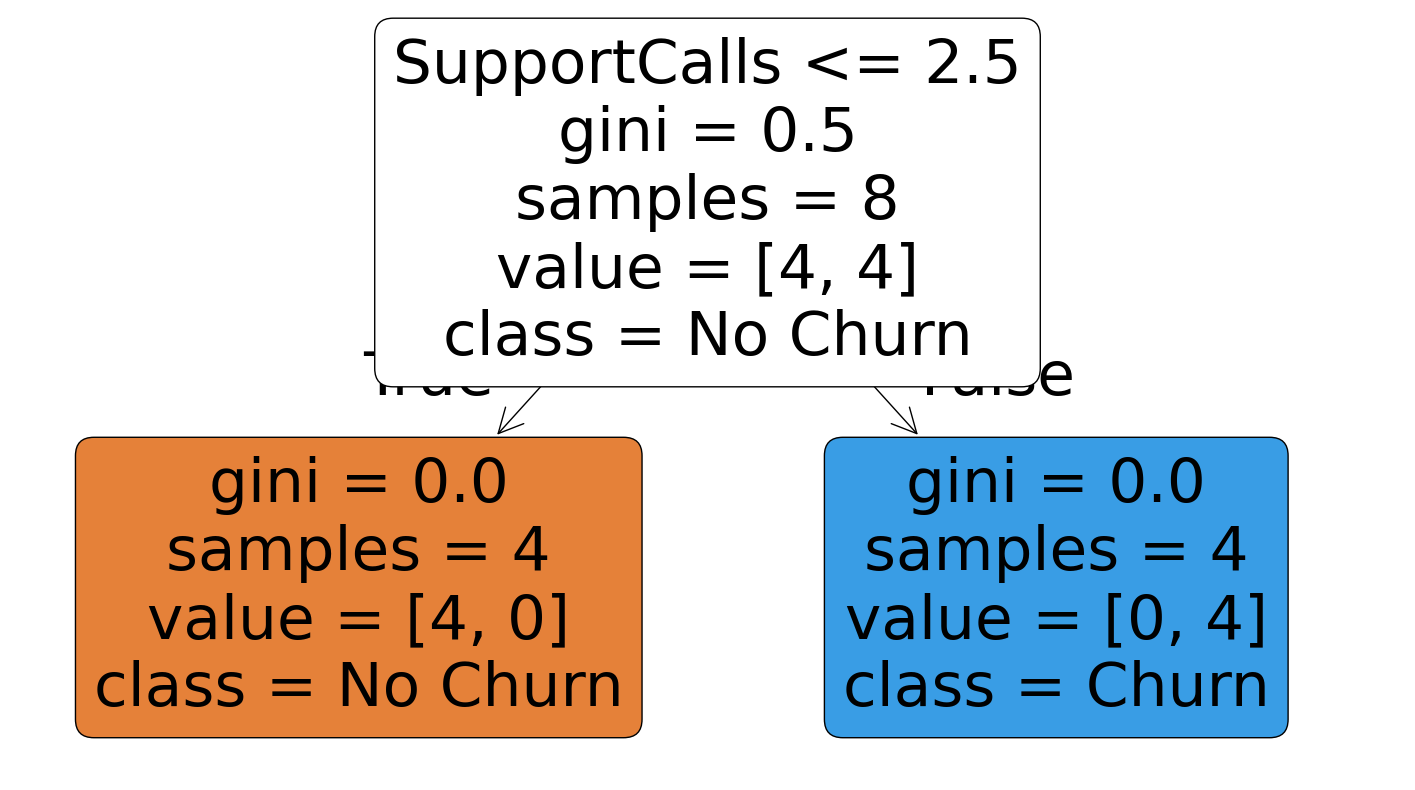

In [15]:
plt.figure(figsize=(18,10))

plot_tree(model,feature_names=X.columns,
          class_names=["No Churn","Churn"],
          filled=True,rounded=True)
plt.show()

In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})
importance.sort_values(by="Importance",ascending=False)

,Feature,Importance
3,SupportCalls,1.0
0,Age,0.0
1,Tenure,0.0
2,MonthlyCharges,0.0
4,ContractType_One year,0.0
5,ContractType_Two year,0.0


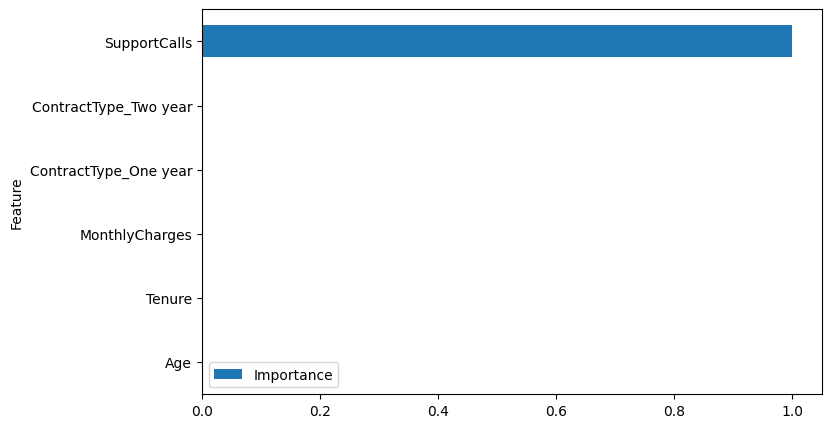

In [19]:
importance.sort_values(by="Importance").plot(
    x="Feature",
    y= "Importance",
    kind="barh",
    figsize=(8,5)
)
plt.show()

In [20]:
joblib.dump(model,"../models/decision_tree_model.pkl")

['../models/decision_tree_model.pkl']

In [22]:
new_customer = pd.DataFrame({
    "Age": [28],
    "Tenure": [4],
    "MonthlyCharges": [88],
    "SupportCalls": [5],
    "ContractType_One year": [0],
    "ContractType_Two year": [0]
})

prediction = model.predict(new_customer)

if prediction[0] ==1:
    print("customer is likely to churn")
else:
    print("customer is likely to stay")

customer is likely to churn
